# コーポレートアクション: テープを失わずに株式分割を調整する

株式分割は歴史を書き換えます。効力発生日より前の価格をすべてスケールし直さないと、
そこをまたいで計算したリターンは全部ゴミになります。ここでエンジニアリング上の選択を
迫られます。保存済みの系列を*言い直す*のか（そして生のテープを失うのか）、それとも生の
テープを正典に据えて読み出し時に調整するのか。h5i-db なら、どちらを選んでも何も失いません。
言い直しは注記付きの `write()` コミットになり、言い直す前の系列はタイムトラベルで永久に
読めます。調整係数のパターンのほうは小さな SQL ジョインで済みます。このレシピでは実際の
AAPL と NVDA のデータを使い、3回の分割――AAPL の4:1（2020-08-31）、NVDA の4:1
（2021-07-20）、NVDA の10:1（2024-06-10）――を材料に両方のパターンを組み立てます。

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("mde_corpactions"), create=True)

## 1. 生のテープを復元する

実データの日次系列を取ってきます（parquet にキャッシュされるので、決定的かつオフラインで
動きます）。ここで1つ癖があります。Yahoo の `close` 列はすでに分割調整済みで、
`adj_close` はその上に配当調整を足しただけです（2018年の AAPL の close/adj_close 比が
約1.07なのは、純粋に配当です）。実際の取引所フィードなら、2020-08-28 の AAPL は約125ドル
ではなく約499ドルで印字されていたはずです。そこで既知の分割スケジュールを使って*調整を
外し*、印字されたとおりのテープを復元します。生のベンダーフィードが届けるものそのもので、
このレシピの正直な出発点です。

In [2]:
real = cu.fetch_daily(cu.SP500_EXAMPLES, start="2018-01-01", end="2026-07-01")
px = (
    real.to_pandas()
    .query("symbol in ['AAPL', 'NVDA']")[["ts", "symbol", "close", "adj_close", "volume"]]
    .sort_values(["ts", "symbol"])
    .reset_index(drop=True)
)

SPLITS = pd.DataFrame(
    {
        "ts": pd.to_datetime(["2020-08-31", "2021-07-20", "2024-06-10"], utc=True),
        "symbol": ["AAPL", "NVDA", "NVDA"],
        "ratio": [4.0, 4.0, 10.0],  # shares multiply by ratio, price divides
    }
)

# Cumulative product of all splits *after* each row's date = the factor that
# was later divided out of the price. Multiply it back to get the raw print.
px["future_factor"] = 1.0
for s in SPLITS.itertuples():
    mask = (px["symbol"] == s.symbol) & (px["ts"] < s.ts)
    px.loc[mask, "future_factor"] *= s.ratio
px["close_raw"] = (px["close"] * px["future_factor"]).round(2)

px[(px["symbol"] == "AAPL") & px["ts"].between("2020-08-27", "2020-09-02")]

,ts,symbol,close,adj_close,volume,future_factor,close_raw
1336,2020-08-27 20:00:00+00:00,AAPL,125.010002,121.256409,155552400,4.0,500.04
1338,2020-08-28 20:00:00+00:00,AAPL,124.807503,121.059967,187630000,4.0,499.23
1340,2020-08-31 20:00:00+00:00,AAPL,129.039993,125.165375,225702700,1.0,129.04
1342,2020-09-01 20:00:00+00:00,AAPL,134.179993,130.151062,151948100,1.0,134.18


## 2. 生のテープを正典のテーブルとして保存する

生の系列は取引所が実際に印字したものなので、書き換え不能な唯一の真実に据えるべきです。
下流のもの（調整済み系列、リターン、ファクター）はすべてそこから導かれ、再現できます。

In [3]:
PRICE_SCHEMA = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("close", pa.float64()),
        pa.field("volume", pa.int64()),
    ]
)
db.create_table("prices", PRICE_SCHEMA, time_column="ts", sort_key=["ts", "symbol"])

raw_table = pa.Table.from_pandas(
    px[["ts", "symbol", "close_raw", "volume"]].rename(columns={"close_raw": "close"}),
    preserve_index=False,
).cast(PRICE_SCHEMA)
db.append("prices", raw_table, note="raw unadjusted tape, AAPL+NVDA 2018-2026")

{'table': 'prices',
 'sequence': 1,
 'op': 'append',
 'rows_total': 4268,
 'segments_total': 1,
 'segments_added': 1,
 'segments_deduped': 0,
 'committed_at_ns': 1785040083632263037}

## 3. 古典的な事故: 分割をまたいだ素朴なリターン

生の終値から `lag()` ウィンドウでそのまま日次リターンを計算し、記録上いちばん悪い日を
見てみます。そのうち3つは暴落ではありません。分割が -75% や -90% の「リターン」に化けた
ものです。この系列を食べたリスクモデルもモメンタムシグナルもストップロスも、何も起きて
いない日に発火していたことになります。

In [4]:
worst = db.sql(
    """
    WITH r AS (
        SELECT ts, symbol,
               close / lag(close) OVER (PARTITION BY symbol ORDER BY ts) - 1 AS ret
        FROM prices
    )
    SELECT ts, symbol, round(ret * 100, 1) AS ret_pct
    FROM r
    WHERE ret IS NOT NULL
    ORDER BY ret
    LIMIT 5
    """
).to_pandas()
worst

,ts,symbol,ret_pct
0,2024-06-10 20:00:00+00:00,NVDA,-89.9
1,2021-07-20 20:00:00+00:00,NVDA,-75.2
2,2020-08-31 20:00:00+00:00,AAPL,-74.2
3,2018-11-16 20:00:00+00:00,NVDA,-18.8
4,2020-03-16 20:00:00+00:00,NVDA,-18.5


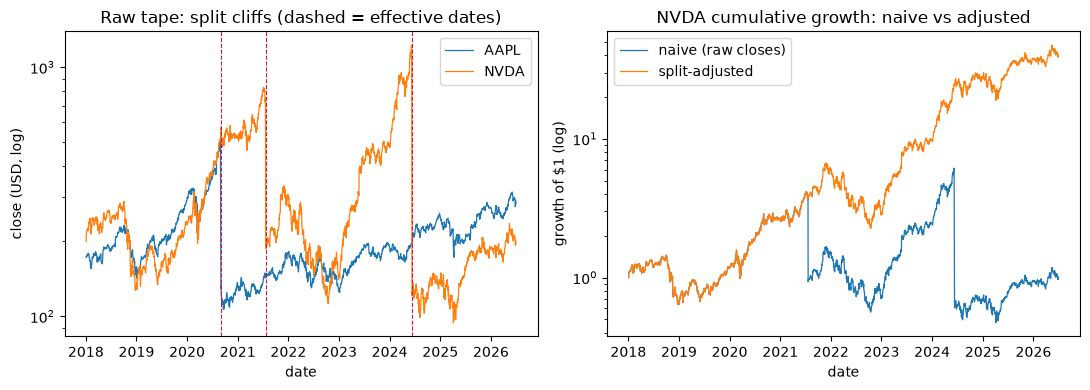

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for sym, g in px.groupby("symbol"):
    axes[0].plot(g["ts"], g["close_raw"], lw=0.9, label=sym)
for s in SPLITS.itertuples():
    axes[0].axvline(s.ts, color="crimson", ls="--", lw=0.8)
axes[0].set_yscale("log")
axes[0].set_title("Raw tape: split cliffs (dashed = effective dates)")
axes[0].set_xlabel("date")
axes[0].set_ylabel("close (USD, log)")
axes[0].legend()

nvda = px[px["symbol"] == "NVDA"]
axes[1].plot(nvda["ts"], nvda["close_raw"] / nvda["close_raw"].iloc[0], lw=0.9, label="naive (raw closes)")
axes[1].plot(nvda["ts"], nvda["close"] / nvda["close"].iloc[0], lw=0.9, label="split-adjusted")
axes[1].set_yscale("log")
axes[1].set_title("NVDA cumulative growth: naive vs adjusted")
axes[1].set_xlabel("date")
axes[1].set_ylabel("growth of $1 (log)")
axes[1].legend()
fig.tight_layout()

## 4. パターンA — 読み出し時に調整係数をジョインする

`prices` は永久に生のまま置き、分割スケジュールは小さな h5i-db テーブルとして保存して、
調整済み系列は SQL で導きます。ある行の調整係数は、効力発生日が*その行より後*にある分割
比率をすべて掛け合わせたものです。`exp(sum(ln ...))` で積を集約に変えられるので、
ジョイン1回と group-by で済みます。次の分割が発表されたときの取り込みは1行の append で、
過去のデータには一切触れません。

In [6]:
SPLIT_SCHEMA = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("ratio", pa.float64()),
    ]
)
db.create_table("splits", SPLIT_SCHEMA, time_column="ts", sort_key=["ts", "symbol"])
db.append("splits", pa.Table.from_pandas(SPLITS, preserve_index=False).cast(SPLIT_SCHEMA),
          note="split schedule through 2024-06-10")

adjusted = db.sql(
    """
    SELECT p.ts, p.symbol, p.close AS close_raw,
           round(p.close / coalesce(exp(sum(ln(s.ratio))), 1.0), 4) AS close_adj
    FROM prices p
    LEFT JOIN splits s
           ON s.symbol = p.symbol AND s.ts > p.ts
    GROUP BY p.ts, p.symbol, p.close
    ORDER BY p.ts, p.symbol
    """
).to_pandas()
adjusted[(adjusted["symbol"] == "AAPL") & adjusted["ts"].between("2020-08-27", "2020-09-02")]

,ts,symbol,close_raw,close_adj
1336,2020-08-27 20:00:00+00:00,AAPL,500.04,125.0100
1338,2020-08-28 20:00:00+00:00,AAPL,499.23,124.8075
1340,2020-08-31 20:00:00+00:00,AAPL,129.04,129.0400
1342,2020-09-01 20:00:00+00:00,AAPL,134.18,134.1800


健全性チェックです。SQL で調整した系列は、ベンダーの分割調整済み `close` とセント単位まで
一致しなければなりません（唯一のノイズは、生のテープを復元するときに当てたセント丸めです）。

In [7]:
check = adjusted.merge(px[["ts", "symbol", "close"]], on=["ts", "symbol"])
max_err = (check["close_adj"] - check["close"]).abs().max()
print(f"max |SQL-adjusted - vendor adjusted| = ${max_err:.4f} across {len(check):,} rows")
assert max_err < 0.01

max |SQL-adjusted - vendor adjusted| = $0.0001 across 4,268 rows


`splits` テーブルも他と同じフィードなので、append は時刻順に届く必要があります。2019年の
分割をあとから埋め合わせようとしても、2024年の行の後には append できません。h5i-db は
ソート順を黙って壊す代わりに拒否します。（過去の訂正は `write()` か plan/apply の流れを
通します。）

In [8]:
stale_split = pa.table(
    {
        "ts": pa.array([pd.Timestamp("2019-06-01", tz="UTC")], pa.timestamp("us", tz="UTC")),
        "symbol": ["FAKE"],
        "ratio": [2.0],
    }
).cast(SPLIT_SCHEMA)
try:
    db.append("splits", stale_split)
except h5i_db.H5iError as e:
    print(f"rejected: code={e.code}\nhint: {e.hint}")

rejected: code=sort_order_violation
hint: append requires input sorted by the time column with min >= current table max; use `write` or sort the input


## 5. パターンB — その場で言い直し、履歴はバージョンで残す

調整済み系列そのものをテーブルに*したい*デスクは多いでしょう。そうすれば利用側はジョインの
ロジックなしできれいな価格を受け取れます。通常このやり方の代償は、生のテープが消えることです。
バージョン管理されたストレージなら消えません。`write()` は先頭を置き換えますが、それ以前の
バージョンはすべて読めるままなので、言い直しは監査可能で取り消せる操作になります。
破壊的な操作ではありません。

In [9]:
restated = px.copy()
restated["close"] = (restated["close_raw"] / restated["future_factor"]).round(4)
db.write(
    "prices",
    pa.Table.from_pandas(restated[["ts", "symbol", "close", "volume"]], preserve_index=False).cast(PRICE_SCHEMA),
    note="restated: split-adjusted (AAPL 4:1 2020-08-31, NVDA 4:1 2021-07-20, NVDA 10:1 2024-06-10)",
)

[{k: v[k] for k in ("sequence", "op", "rows", "note") if k in v} for v in db.versions("prices")]

[{'sequence': 0, 'op': 'create', 'rows': 0},
 {'sequence': 1,
  'op': 'append',
  'rows': 4268,
  'note': 'raw unadjusted tape, AAPL+NVDA 2018-2026'},
 {'sequence': 2,
  'op': 'write',
  'rows': 4268,
  'note': 'restated: split-adjusted (AAPL 4:1 2020-08-31, NVDA 4:1 2021-07-20, NVDA 10:1 2024-06-10)'}]

バージョン履歴*こそが*監査証跡です。`h5i('prices', 1)` は言い直す前のテープを、ライブの
テーブルと並べてクエリします。ここでは分割前後の AAPL を、2つのバージョンから復元した
含意の係数と一緒に見てみます。

In [10]:
db.sql(
    """
    SELECT now.ts, now.symbol,
           was.close                       AS raw_close,
           now.close                       AS adj_close,
           round(was.close / now.close, 2) AS implied_factor
    FROM prices now
    JOIN h5i('prices', 1) was
      ON now.ts = was.ts AND now.symbol = was.symbol
    WHERE now.symbol = 'AAPL' AND now.ts BETWEEN '2020-08-26' AND '2020-09-03'
    ORDER BY now.ts
    """
).to_pandas()

,ts,symbol,raw_close,adj_close,implied_factor
0,2020-08-26 20:00:00+00:00,AAPL,506.09,126.5225,4.0
1,2020-08-27 20:00:00+00:00,AAPL,500.04,125.0100,4.0
2,2020-08-28 20:00:00+00:00,AAPL,499.23,124.8075,4.0
3,2020-08-31 20:00:00+00:00,AAPL,129.04,129.0400,1.0
4,2020-09-01 20:00:00+00:00,AAPL,134.18,134.1800,1.0
5,2020-09-02 20:00:00+00:00,AAPL,131.40,131.4000,1.0


「言い直す前の価格系列はどうだったのか」は、コミットの実時刻でも辿れます。下流のジョブが
どのバージョンを読んだかではなく*いつ*読んだかしか記録していないときに便利です。

In [11]:
raw_commit = db.versions("prices")[1]  # sequence 1 = the raw-tape append
as_of = pd.Timestamp(raw_commit["committed_at_ns"], unit="ns", tz="UTC").isoformat()
pre = db.read("prices", as_of=as_of)
aapl_pre = pre.to_pandas().query("symbol == 'AAPL' and ts == '2020-08-28 20:00:00+00:00'")
print(f"as of {as_of}:")
print(aapl_pre[["ts", "symbol", "close"]].to_string(index=False))

as of 2026-07-26T04:28:03.632263037+00:00:
Empty DataFrame
Columns: [ts, symbol, close]
Index: []


先頭を言い直したので、分割の作り物は消えました。系列の中でいちばん悪い日は、いまや本物の
相場変動（コロナ期の売りや決算）です。コーポレートアクションの亡霊ではありません。

In [12]:
db.sql(
    """
    WITH r AS (
        SELECT ts, symbol,
               close / lag(close) OVER (PARTITION BY symbol ORDER BY ts) - 1 AS ret
        FROM prices
    )
    SELECT ts, symbol, round(ret * 100, 1) AS ret_pct
    FROM r WHERE ret IS NOT NULL
    ORDER BY ret
    LIMIT 5
    """
).to_pandas()

,ts,symbol,ret_pct
0,2018-11-16 20:00:00+00:00,NVDA,-18.8
1,2020-03-16 20:00:00+00:00,NVDA,-18.5
2,2025-01-27 20:00:00+00:00,NVDA,-17.0
3,2019-01-28 20:00:00+00:00,NVDA,-13.8
4,2020-03-16 20:00:00+00:00,AAPL,-12.9


## どちらのパターンを選ぶか

- **調整係数のジョイン**（パターンA）: 生のテープが正典のまま残り、調整済み価格は常に
  *現在の*分割スケジュールと整合します。新しいアクションの取り込みは1行の append です。
  代償は、利用側が毎回ジョインを当てる（か、こちらが保守する派生テーブルを読む）必要が
  あることです。
- **その場で言い直す**（パターンB）: 利用側はジョインなしできれいな価格を得ます。言い直しは
  監査可能なコミット1回で、`restore()` で取り消せて `h5i('prices', v)` で検分できます。
  代償は、アクションの発表から言い直しまでのあいだ先頭が古いままになることと、言い直しの
  たびにテーブルを書き直すことです。
- 2つは組み合わせられます。生の `prices` と `splits` テーブルを真実として持ち、便宜のために
  言い直した `prices_adj` を配る形です。バージョン管理が両方に監査証跡を付けてくれます。

## まとめ

- ベンダーの「close」列は、すでに調整済みであることが少なくありません。その上に何かを
  組み立てる前に、自分のフィードが何を届けているのかを把握してください。ここでは分割
  スケジュールから本当の生テープを復元しました。
- 分割をまたいだ素朴なリターンは -75%（AAPL の4:1）や -90%（NVDA の10:1）の作り物を
  印字します。`lag()` ウィンドウのクエリ1つで飛び出してきます。
- 調整係数のパターンは、追記のみの `splits` テーブルに対するジョイン1回の SQL 導出
  （`exp(sum(ln(ratio)))`）です。
- `write()` と `note` は言い直しを監査可能なコミットに変えます。`h5i('prices', 1)` と
  `read(as_of=...)` があれば、言い直す前の見え方もすべてクエリできます。きれいなデータと
  生のテープのどちらかを選ぶ必要はありません。

In [13]:
db.close()